**Foundational Concepts**

Q1 What is a random variable? Explain the difference between a random variable and a regular variable you might use in algebra.
-  A random variable is a function where the input is the outcome of a random experiment and the output is a numerical value. A regular variable has a fixed value determined by an equation, while a random variable has possible values determined by chance.

Q2 What distinguishes a continuous random variable from a discrete random variable?** Give an example of each.
- A continuous random variable takes on any number on an interval so there are infinitely possible values(THESE ARE MEASURABLE). An example of continuous is speed, height, weight,etc. While discrete random variables allow you to COUNT specific outcomes. Examples: number of students in a class, number of coin, number of players in a team, etc.

Q3 What is a cumulative distribution function (CDF)? What are its inputs and what values does it return?
- The cumulative distribution function (CDF) often recognized as F(x)= P(X ≤ x)  gives the probability that a random variable takes on a value less than or equal to a given value. The CDF's input is any real number x, while output is a probability - so between 0 and 1.
  
Q4 How would you use the probability density function (PDF) to find P(a < X < b)?
- By integrating the PDF from a to b. The area under the PDF curve between a and b gives the probability.The pdf is the slope of the cdf. Unlike cdf, the pdf can be greater than 1.

Q5 Explain the relationship between a PDF and a CDF. How would you calculate one from the other?
- The PDF is the derivative of the CDF: f(x) = F'(x) = dF/dx
- The CDF is the integral of the PDF: F(x) = ∫₋∞ˣ f(t)dt

In [1]:
from scipy.stats import beta
from scipy.stats import norm
from scipy.stats import gamma
from scipy.stats import expon
from scipy.stats import uniform
import numpy as np
import matplotlib.pyplot as plt

Q6 The probability density function for an exponential distribution with rate parameter λ is:

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

Suppose buses arrive at a bus stop according to an exponential distribution with rate λ = 0.5 per minute. This means the average waiting time is 1/λ = 2 minutes.

(A) Write Python code using scipy.stats.expon to plot the PDF of the exponential distribution with rate λ = 0.5. On the same plot, add the PDF for an exponential distribution with rate λ = 1.0 (scale = 1).

(B) What is the average waiting time for both distributions?

The normal distribution is characterized by two parameters: mean μ (mu) and standard deviation σ (sigma).


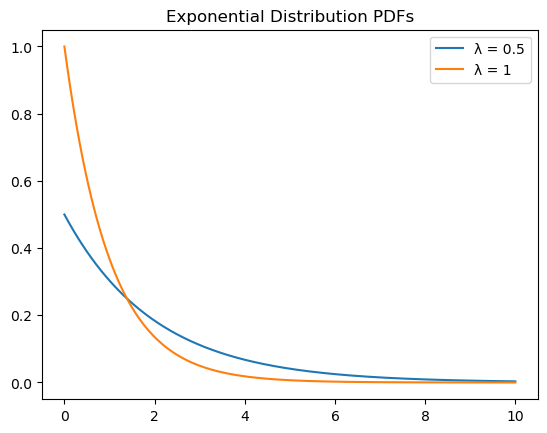

In [16]:
#dist = expon(scale = 1 /0.5)
#a) scale = 1 / λ   --- larger scale leads to slower decay
x = np.linspace(0,10,300)
pdf_05 = expon.pdf(x, scale=1/0.5) 
pdf_1 = expon.pdf(x, scale = 1/ 1)

plt.figure()
plt.plot(x, pdf_05, label='λ = 0.5')
plt.plot(x, pdf_1, label='λ = 1')
plt.title("Exponential Distribution PDFs")
plt.legend()
plt.show()

#b) What is the average waiting time for both distributions?

- for distribution 1: 1 /0.5 = 2 minutes
- for distribution 2: 1/1 = 1 minute

7. The probability density function for a normal distribution is:

 $$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
 $$
 
 

(A) Let the mean μ = 50 and standard deviation σ = 10. Plot the density.

(B) Generate N=100 values from a Normal(50, 10) distribution. What proportion of your sample falls within one standard deviation of the mean (between 40 and 60)?

(C) The theoretical proportion is 68%. Calculate the simulation error (absolute difference).

(D) Repeat (B) and (C) 10,000 times. Create a histogram of the simulation error with 100 bins.

(E) Repeat (D) with N=1000. Create a plot which overlays the histogram of the simulartion errors from part (D) and part (E).

(F) What do the differences in the histograms in part (E) indicate?

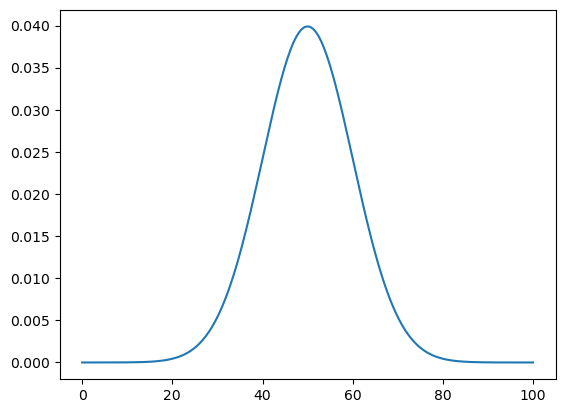

[50.67864544 58.97025318 65.32909512 53.14067739 52.63346636 51.88699585
 45.75599946 31.95987309 68.79656209 74.57489063 36.36144635 72.4439596
 56.27382674 45.88016206 45.14357231 37.35458272 56.68390132 49.5450338
 27.02000957 47.81221625 60.07985125 57.65785109 28.68241082 59.45009313
 35.52238069 62.85331316 47.0750793  58.04107179 40.21193705 49.33402601
 59.37277721 76.0511138  41.42051565 51.32365108 35.66941523 30.50198582
 46.3490509  51.51534875 71.58282378 68.98230897 42.56454447 64.85685651
 60.44555338 54.10894816 43.14479319 45.20637013 33.59804418 57.89993343
 51.11766503 41.96112273 63.27889143 54.9206146  58.4676256  54.84887979
 51.12501185 45.60479272 47.48543244 60.39839348 28.77141563 48.93763357
 44.0303736  42.5207461  56.45747841 52.14762246 53.88643246 38.43079084
 47.87458191 69.64032875 52.74413034 61.29394835 50.8692173  38.05449191
 45.27697151 54.29014467 41.67437555 52.10926106 54.21920443 44.5662142
 45.83484378 52.7333261  44.29043699 31.07307834 48.30

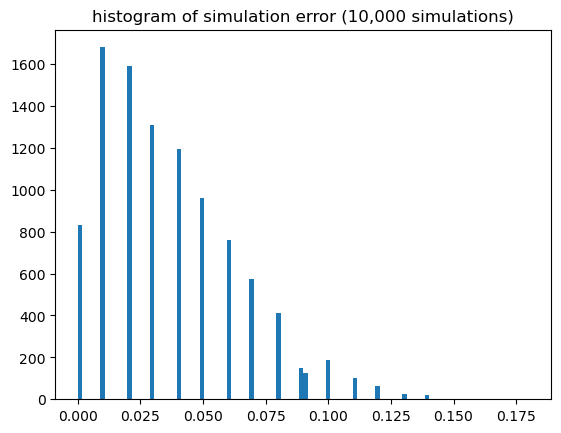

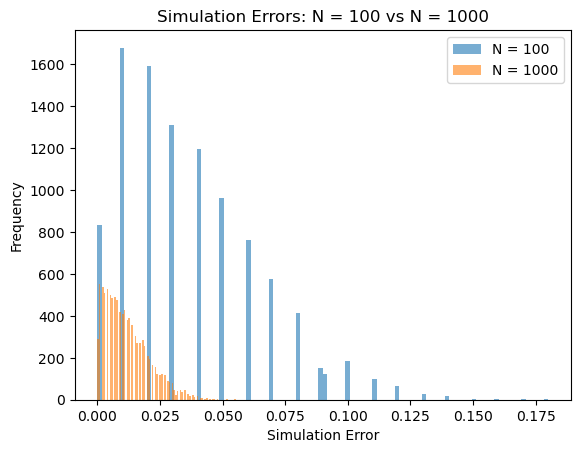

In [17]:
#dist = norm(loc = 50, scale= 10)
#a) plot density pdf
x = np.linspace(0,100, 300)
density_plot = norm.pdf(x, loc = 50, scale = 10)
plt.figure()
plt.plot(x, density_plot, label = "pdf for norm. distribution")
plt.show()

#b) 
sample = norm.rvs(loc = 50, scale = 10, size=100) # explore rvs
print(sample)
findings = (sample >= 40) & (sample <= 60)
observed_proportion = findings.mean()
print("proportion = " + str(observed_proportion))

#c. error=∣observed−theoretical∣
simulation_error = abs(observed_proportion - 0.68)
print("simulation_error " + str(simulation_error))

#d)
errors = []
for x in range(10000):
    sample_10000 = norm.rvs( loc = 50, scale = 10, size = 100) # N = 100
    result = (40 <= sample_10000) & (sample_10000 <= 60)
    ob_proportion = result.mean()
    SE = abs(ob_proportion - 0.68)

    errors.append(SE)
    
plt.hist(errors, bins = 100)
plt.title("histogram of simulation error (10,000 simulations)")
plt.show()

#e) Repeat (D) with N=1000. Create a plot which overlays the histogram of the simulation errors from part (D) and part (E).
errors_1000 = []
for x in range(10000):
    sample_1000 = norm.rvs(loc = 50, scale = 10, size = 1000) #N = 1000
    sample_results = (sample_1000 >= 40) & (sample_1000 <= 60)
    sample_results = sample_results.mean()
    SE = abs(sample_results - 0.68)

    errors_1000.append(SE)

plt.figure()
plt.hist(errors, bins=100, alpha=0.6, label="N = 100")
plt.hist(errors_1000, bins=100, alpha=0.6, label="N = 1000")
plt.xlabel("Simulation Error")
plt.ylabel("Frequency")
plt.title("Simulation Errors: N = 100 vs N = 1000")
plt.legend()
plt.show()


#F) What do the differences in the histograms in part (E) indicate?
- The difference in plots indicate that larger sample sizes lead to smaller simulation error,
 while smaller sample sizes have larger simulation error ranges. 

Q8 The probability density function for a gamma distribution with shape parameter k and rate parameter λ is:

 $$
 f(x) = \frac{\lambda^k}{\Gamma(k)} x^{k-1} e^{-\lambda x}, \quad x \geq 0
 $$

The gamma distribution is often used to model waiting times for multiple events. If individual events occur according to an exponential distribution with rate λ, then the time until the k-th event follows a gamma distribution.

(A) In a single figure, plot the density functions when λ=1 and k=1, 2, 3, and 5.

(B) Describe how the shape of the distribution changes as k increases.

(C) Generate 10,000 random samples from a Gamma(5, 2) distribution. Calculate the sample mean. How does it compare to the theoretical mean k/λ = 5/2 = 2.5?

(D) Create a histogram with 100 bins of your simulated values and overlay the theoretical PDF. Do they match?

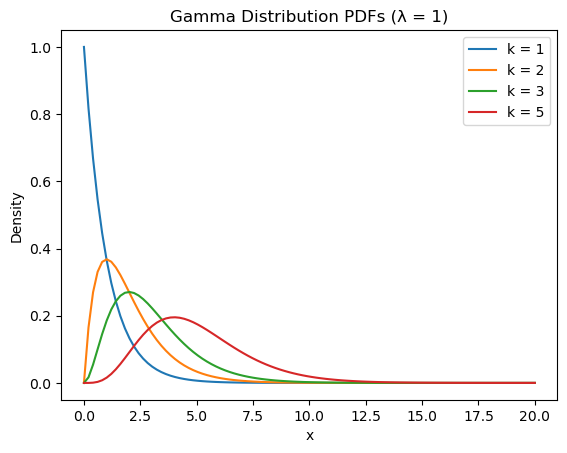

In [18]:
#a) 
x = np.linspace(0, 20, 100)
density_plot1 = gamma.pdf(x, a = 1, scale = 1) # k = a = shape, scale = 1/lambda so 1/1 = 1
density_plot2 = gamma.pdf(x, a = 2, scale = 1)
density_plot3 = gamma.pdf(x, a = 3, scale = 1)
density_plot5 = gamma.pdf(x, a = 5, scale = 1)
plt.figure()
plt.plot(x, density_plot1, label="k = 1")
plt.plot(x, density_plot2, label="k = 2")
plt.plot(x, density_plot3, label="k = 3")
plt.plot(x, density_plot5, label="k = 5")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gamma Distribution PDFs (λ = 1)")
plt.legend()
plt.show()


#b) 
- As k increases, the shape of the distributions gets less skewed and more bell curve shaped; also becomes wider/more spread out.

In [19]:
#c)  Generate 10,000 random samples from a Gamma(5, 2) distribution. Calculate the sample mean. 
# How does it compare to the theoretical mean k/λ = 5/2 = 2.5?

gamma_sample = gamma.rvs(a = 5, scale = 1/2, size = 10000) #scale = 1/rate in this case rate is 2
sample_mean = gamma_sample.mean()
print(sample_mean)

# Because the samples are generated randomly, the sample mean does not equal 2.5 exactly, 
# but it is close to the theoretical mean, as expected for a large sample size.

2.4756997129897966


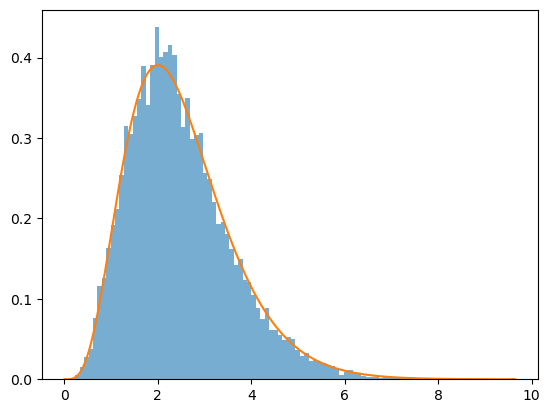

In [20]:
#d) Create a histogram with 100 bins of your simulated values and overlay the theoretical PDF. Do they match?
x = np.linspace(0, gamma_sample.max(), 1000)
plt.figure()
plt.hist(gamma_sample, bins = 100, density = True, alpha = 0.6)
theo_pdf = gamma.pdf(x, a=5, scale=1/2)
plt.plot(x, theo_pdf, label = "Theoretical PDF")
plt.show()

# Answer: Yes, they do match very closely as we can see that the histogram follows the theoretical PDF curve.

Q9 The probability density function for a beta distribution with shape parameters α (alpha) and β (beta) is:

$$
f(x) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1} (1-x)^{\beta-1}, \quad 0 \leq x \leq 1
$$
 

The beta distribution is defined on the interval [0, 1], making it useful for modeling proportions, probabilities, and percentages.

(A) On the same plot, show beta distributions with α = β = 1, α = β = 2, and α = β = 5.

(B) In the same figure, plot Beta(2, 5) and Beta(5, 2).

(C) Comparing the plots in (A) and (B), what happens when α = β? Describe the shape. What happens when α > β? Describe the shape.



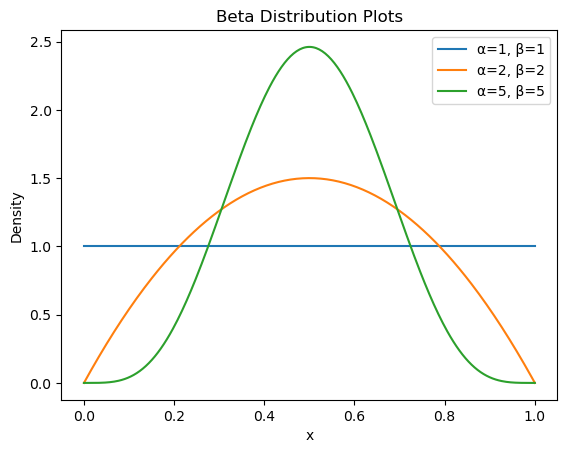

In [21]:
#a) 
x = np.linspace(0, 1, 300)
plt.figure()
plot1 = beta.pdf(x, a=1, b = 1)
plot2 = beta.pdf(x, a=2, b = 2)
plot5 = beta.pdf(x, a=5, b = 5)
plt.plot(x, plot1, label="α=1, β=1")
plt.plot(x, plot2, label="α=2, β=2")
plt.plot(x, plot5, label="α=5, β=5")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Beta Distribution Plots")
plt.show()


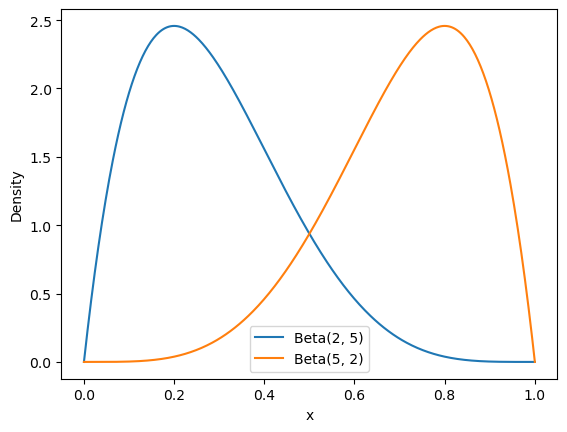

In [22]:
#b) In the same figure, plot Beta(2, 5) and Beta(5, 2).
x = np.linspace(0,1, 500)
plt.figure()
plot_25 = beta.pdf(x, a = 2, b = 5)
plot_52 = beta.pdf(x, a = 5, b = 2)
plt.plot(x, plot_25, label = "Beta(2, 5)")
plt.plot(x, plot_52, label = "Beta(5, 2)")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

#c) Comparing the plots in (A) and (B), what happens when α = β? Describe the shape. What happens when α > β? Describe the shape.

- When a = β the plots share a symmetrical shape with an even split at the point 0.5;
 while when a > b the plot is skewed left. When a > β the distribution is skewed left (peak is at right).


Q10 A mixture distribution combines two or more probability distributions. The PDF of a mixture is:

$$
f(x) = w_1 f_1(x) + w_2 f_2(x) + \cdots + w_k f_k(x)
$$

where 
 are weights (mixing proportions) that sum to 1, and 
 are the component densities.

(A) Give an example of a real-world situation where a mixture distribution might be appropriate.

(B) Generate 10,000 samples from the mixture of two normals: 23: 0.6×Normal(20, 3) + 0.4×Normal(30, 2). (Hint: Approach: For each sample, first randomly decide which component (1 or 2) based on the weights, then draw from that component.) Create a histogram and overlay the theoretical mixture density.

 a) Give an example of a real-world situation where a mixture distribution might be appropriate.

 - A mixture distribution might be appropriate when comparing transportation modes: public transport vs commute by personal vehicle; or exam scores: students who studied vs. students who didn't


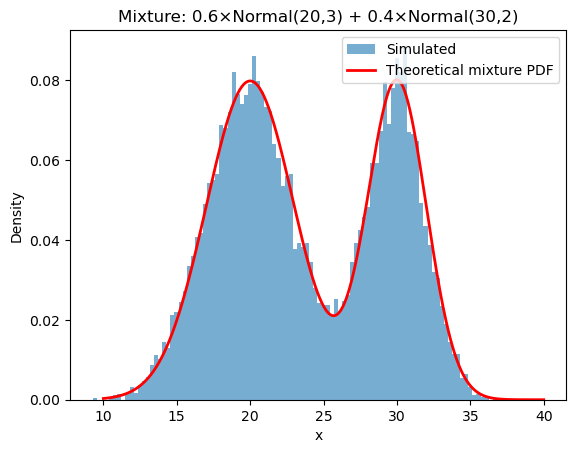

In [23]:
# (B) Generate 10,000 samples from the mixture of two normals: 23: 0.6×Normal(20, 3) + 0.4×Normal(30, 2). (Hint: Approach: For each sample, first randomly decide which component (1 or 2) based on the 
# weights, then draw from that component.) Create a histogram and overlay the theoretical mixture density.

n_samples = 10000
random_samples = []

for i in range(n_samples):
    # randomly choose components based on weights
    if np.random.rand() < 0.6:  # 60% chance
        sample = norm.rvs(loc=20, scale=3)
    else:  # 40% chance
        sample = norm.rvs(loc=30, scale=2)
    random_samples.append(sample)

random_samples = np.array(random_samples)

# plot histogram with mixture PDF
x = np.linspace(10, 40, 1000)
mixture_pdf = 0.6 * norm.pdf(x, loc=20, scale=3) + 0.4 * norm.pdf(x, loc=30, scale=2)

plt.figure()
plt.hist(random_samples, bins=100, density=True, alpha=0.6, label='Simulated')
plt.plot(x, mixture_pdf, 'r-', linewidth=2, label='Theoretical mixture PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Mixture: 0.6×Normal(20,3) + 0.4×Normal(30,2)')
plt.legend()
plt.show()

Q11 Expected Value and Variance.

(A) What does the expected value (mean) of a random variable represent?
- the expected value(mean) represents the weighted average of a random variable in an experiment if the experiment were repeated many times.

(B) For a continuous random variable X with density f(x), write the formula for E[X].
$$
\text{mean} = E[X] = \int_{-\infty}^{\infty} x f_X(x) dx
$$
(C) For a continuous random variable X with density f(x), write the formula for and E[X²]?
$$
\ E[X^2] = \int_{-\infty}^{\infty} x^2 f_X(x) dx
$$
(D) Write the formula for Var(X) in terms of E[X] and E[X²].
$$
\text{variance of X} = V[X] = E[X^2]-\left(E[X] \right)^2
$$

(E) What is the relationship between variance and standard deviation?
- the standard deviation is the square root of variance

(F) What is an advantage of the standard deviation compared to the variance?
- Standard deviation uses same units as the data which is not true for variance

Q12 Suppose X has density function f(x) = 2x for 0 ≤ x ≤ 1, and f(x) = 0 otherwise.

(A)Calculate E[X] using the integral formula.
$$
\ E[X] = \int_{0}^{1} x (2x) dx
$$

(B) Calculate E[X²].
$$
\ E[X]^2 = \int_{0}^{1} x^2 (2x) dx
$$
(C) Calculate Var(X).

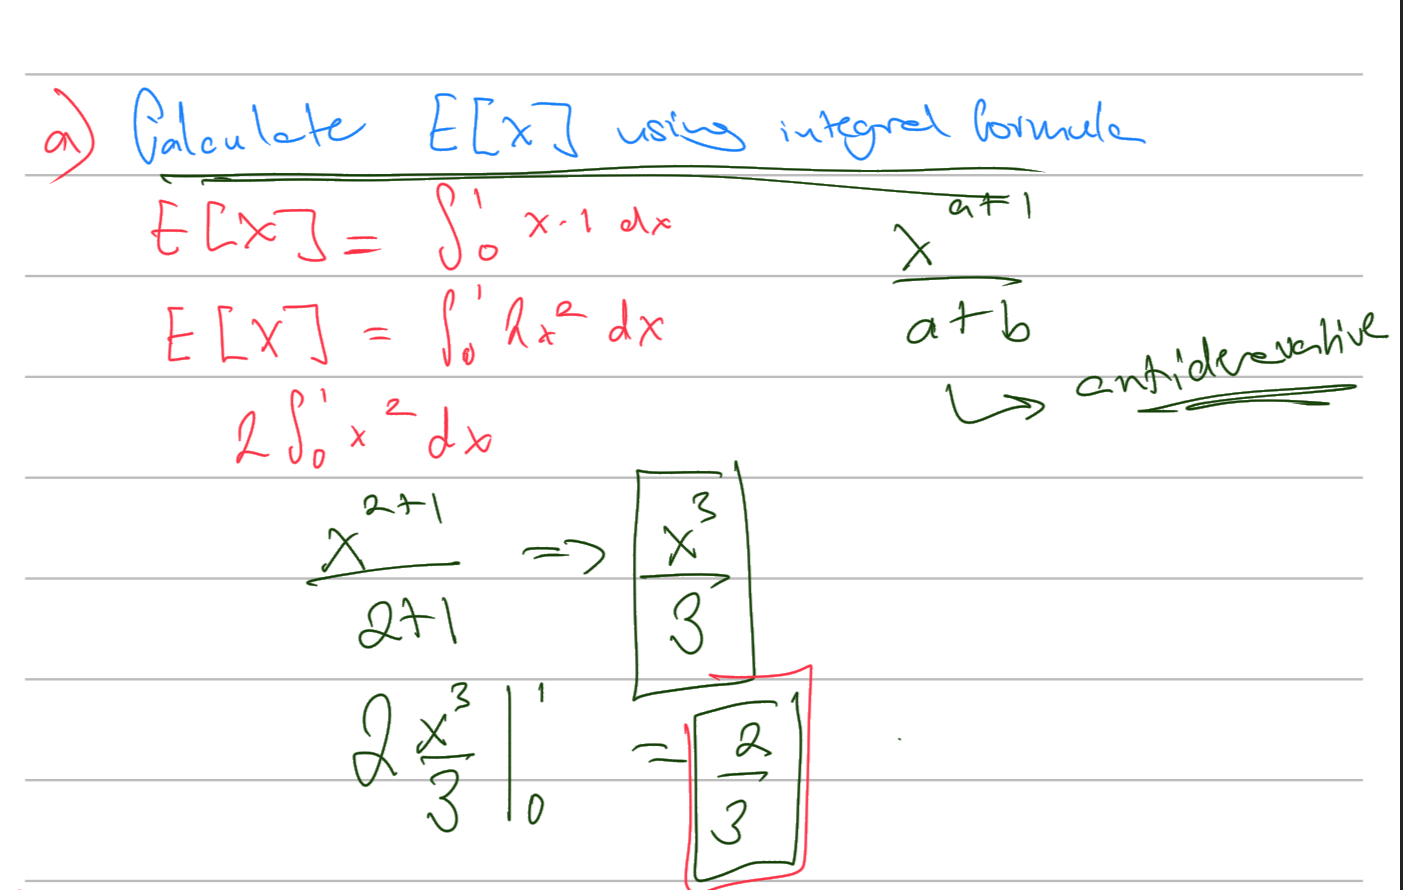

In [6]:
#12a) Calculate E[X] using the integral formula.
from IPython.display import Image
Image(filename="12a.png") 


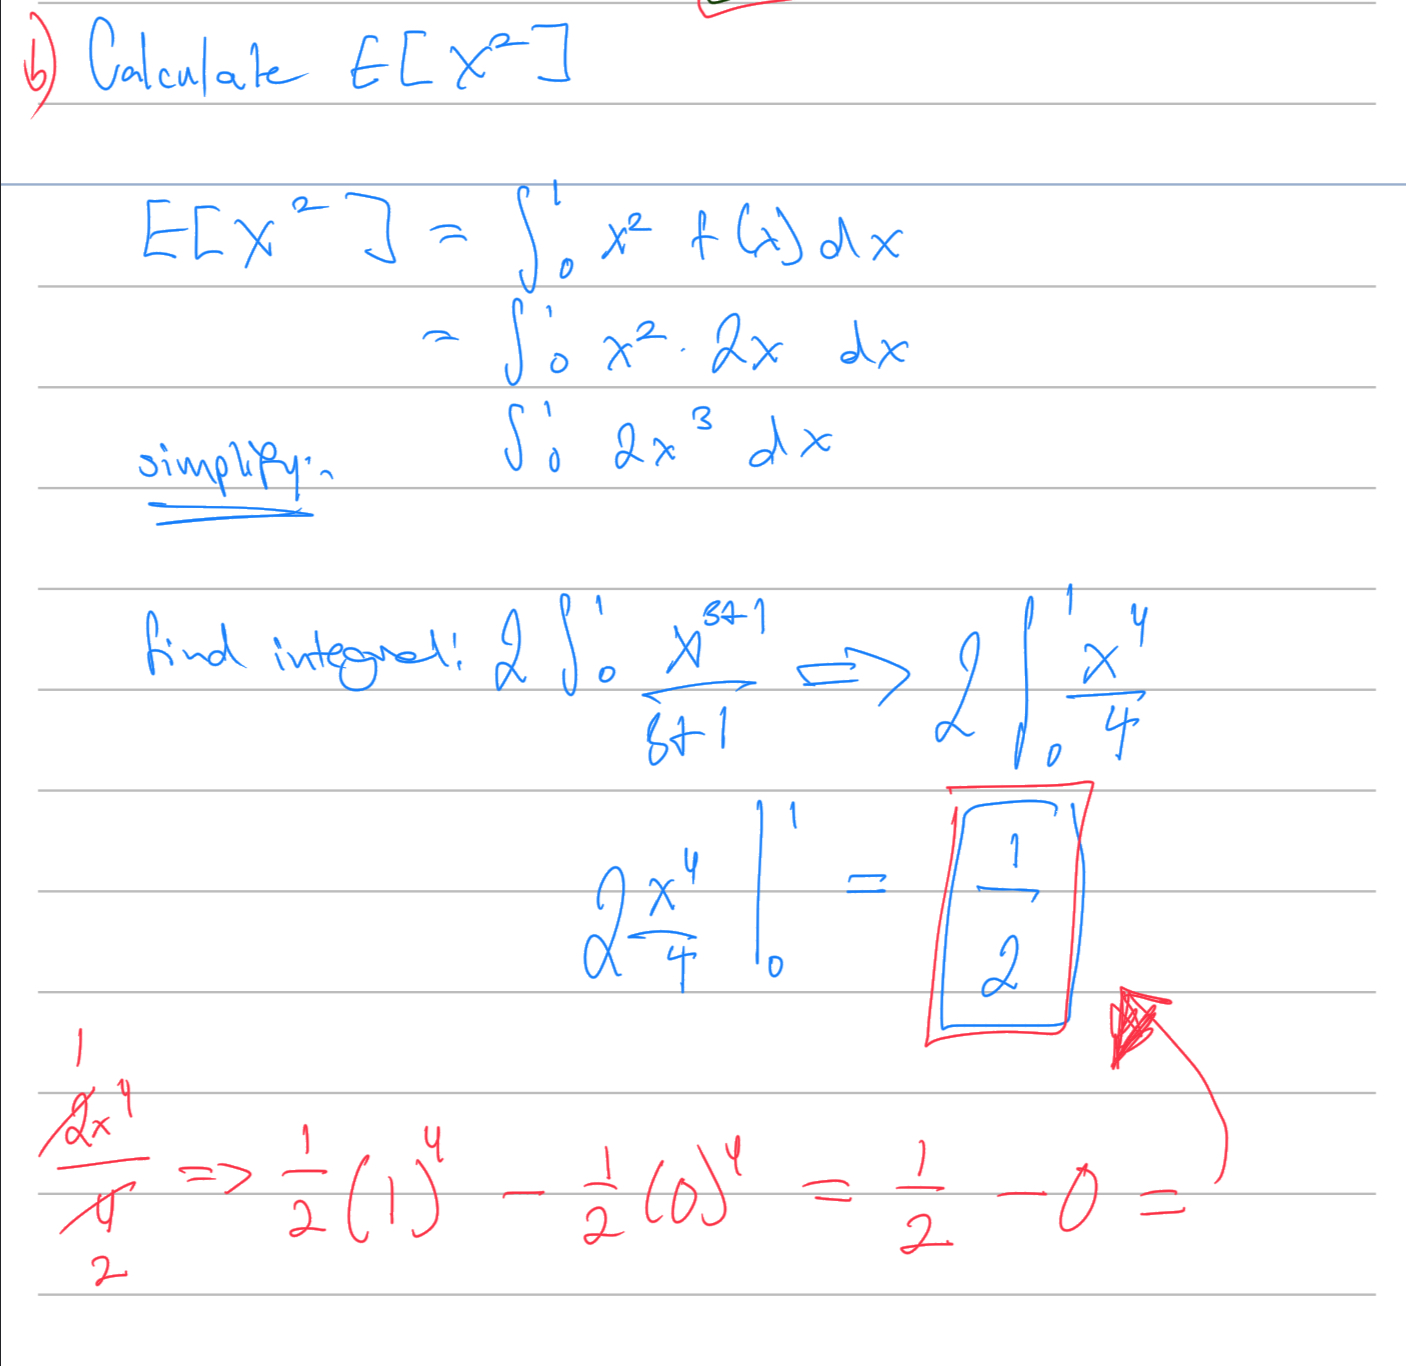

In [7]:
#12b) Calculate E[X²].
from IPython.display import Image
Image(filename="12b.png") 


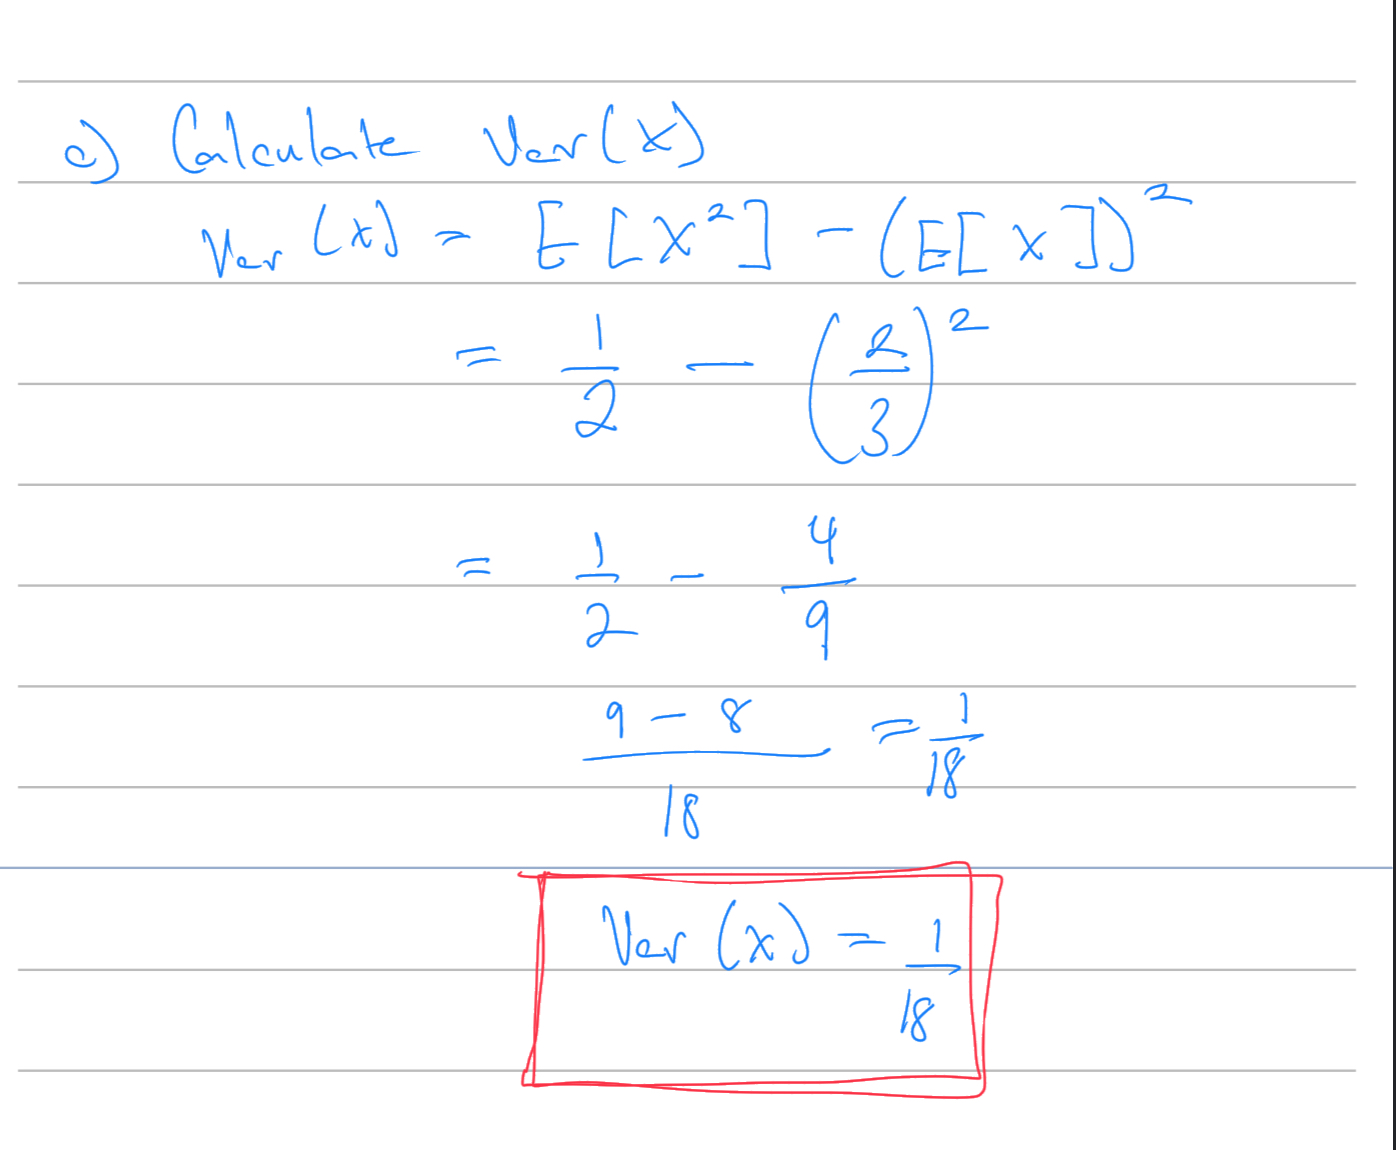

In [8]:
#12c) Calculate Var(X).
from IPython.display import Image
Image(filename="12c.png") 

Q13 If you have a function g(x) that has the right shape for a density (g(x)>0) but doesn’t integrate to 1, how do you find the normalizing constant c so that c·g(x) is a valid PDF?

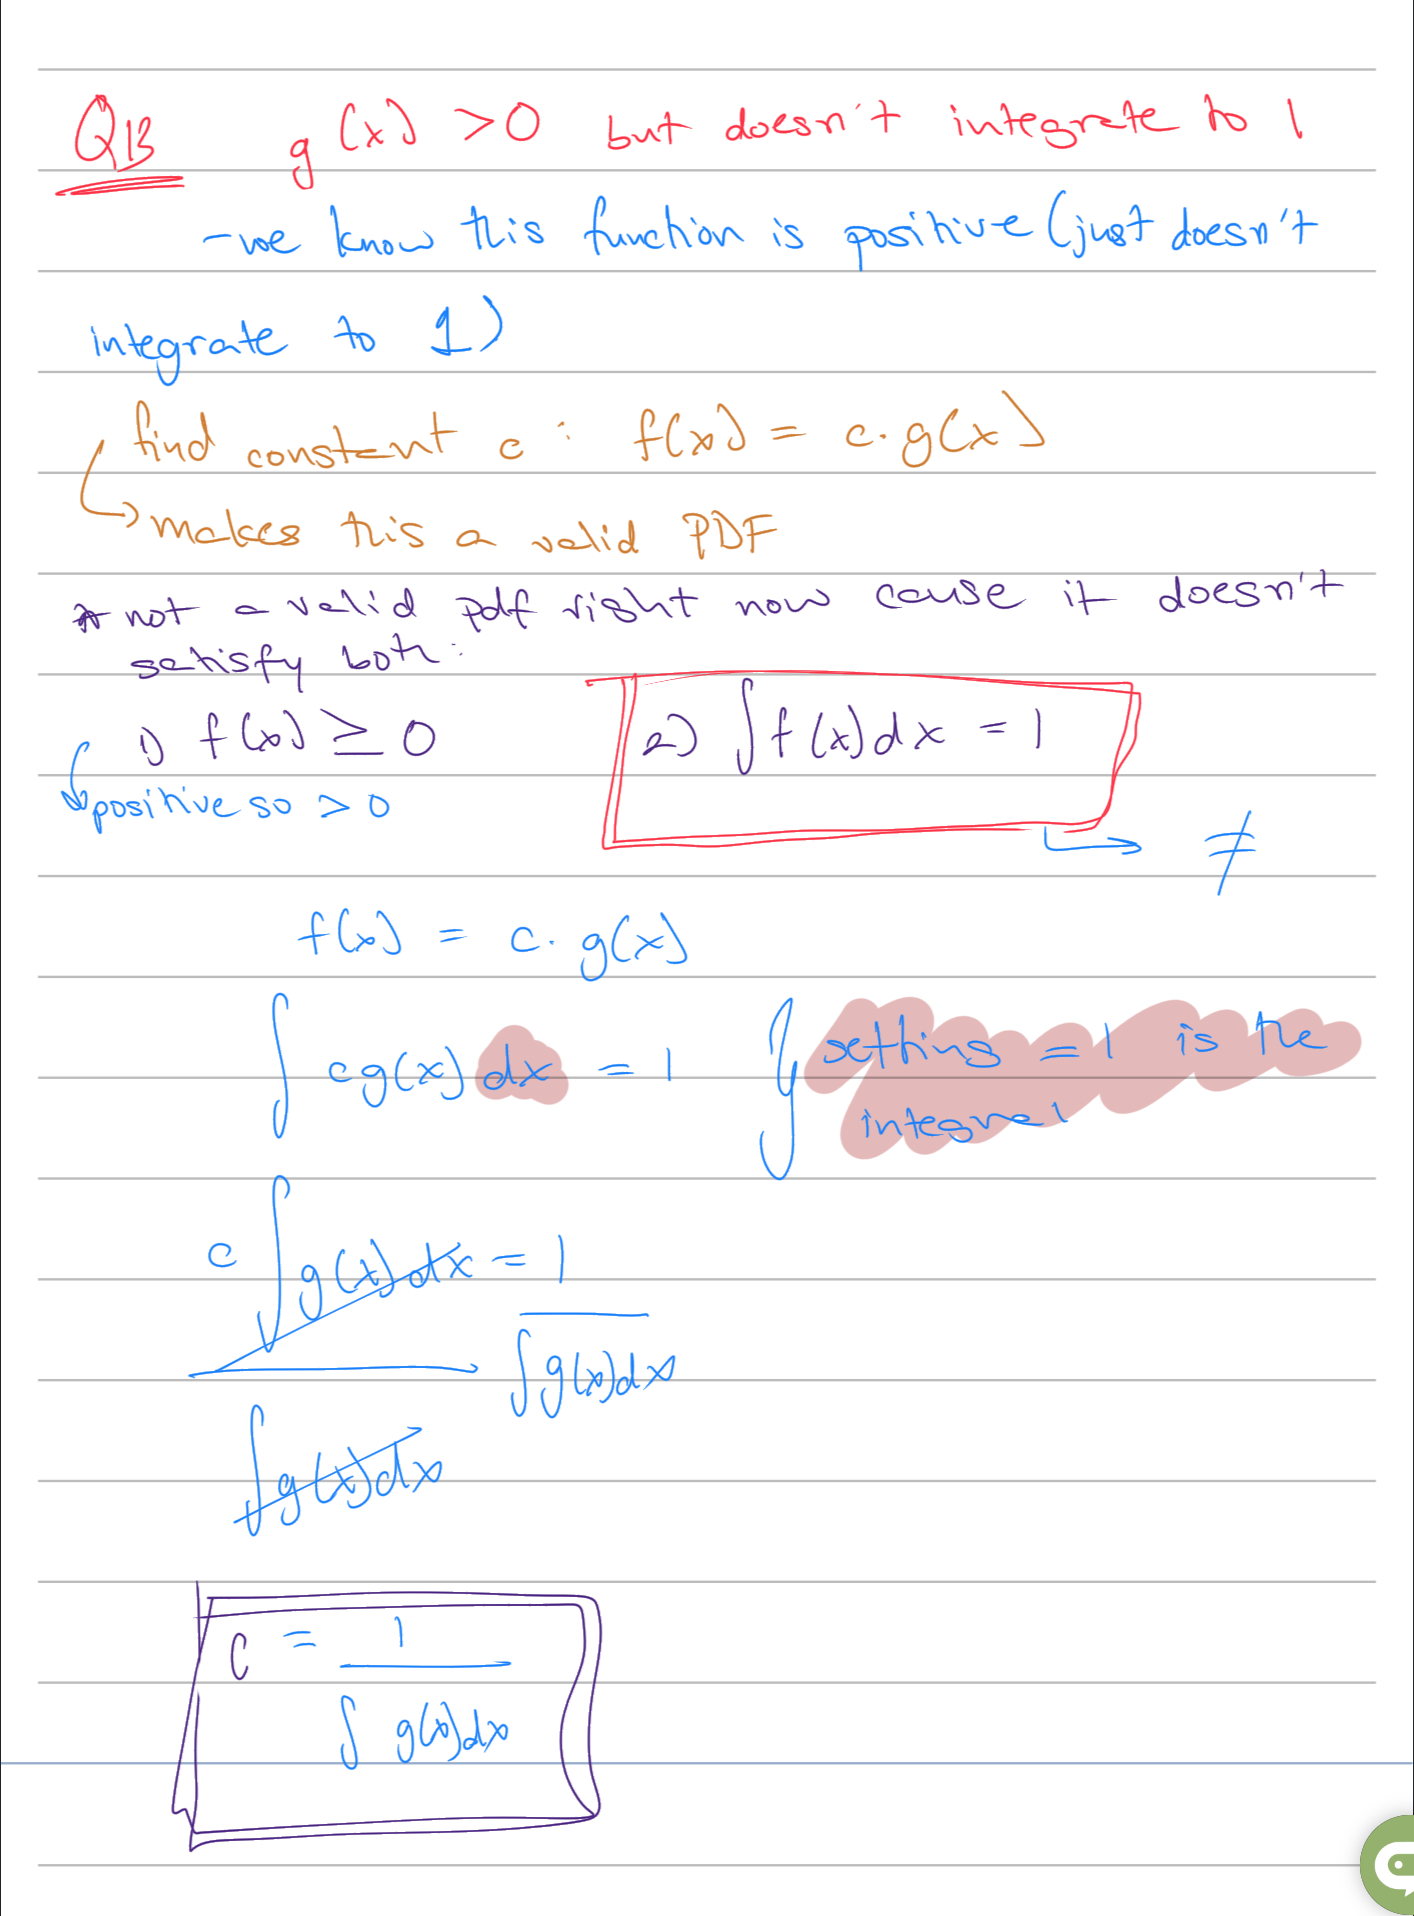

In [9]:
from IPython.display import Image
Image(filename="q13.png") 

Q14 Suppose we have f(x) = c·x² for 0 ≤ x ≤ 2, and f(x) = 0 otherwise. Find the value of c that makes this a valid probability density function.

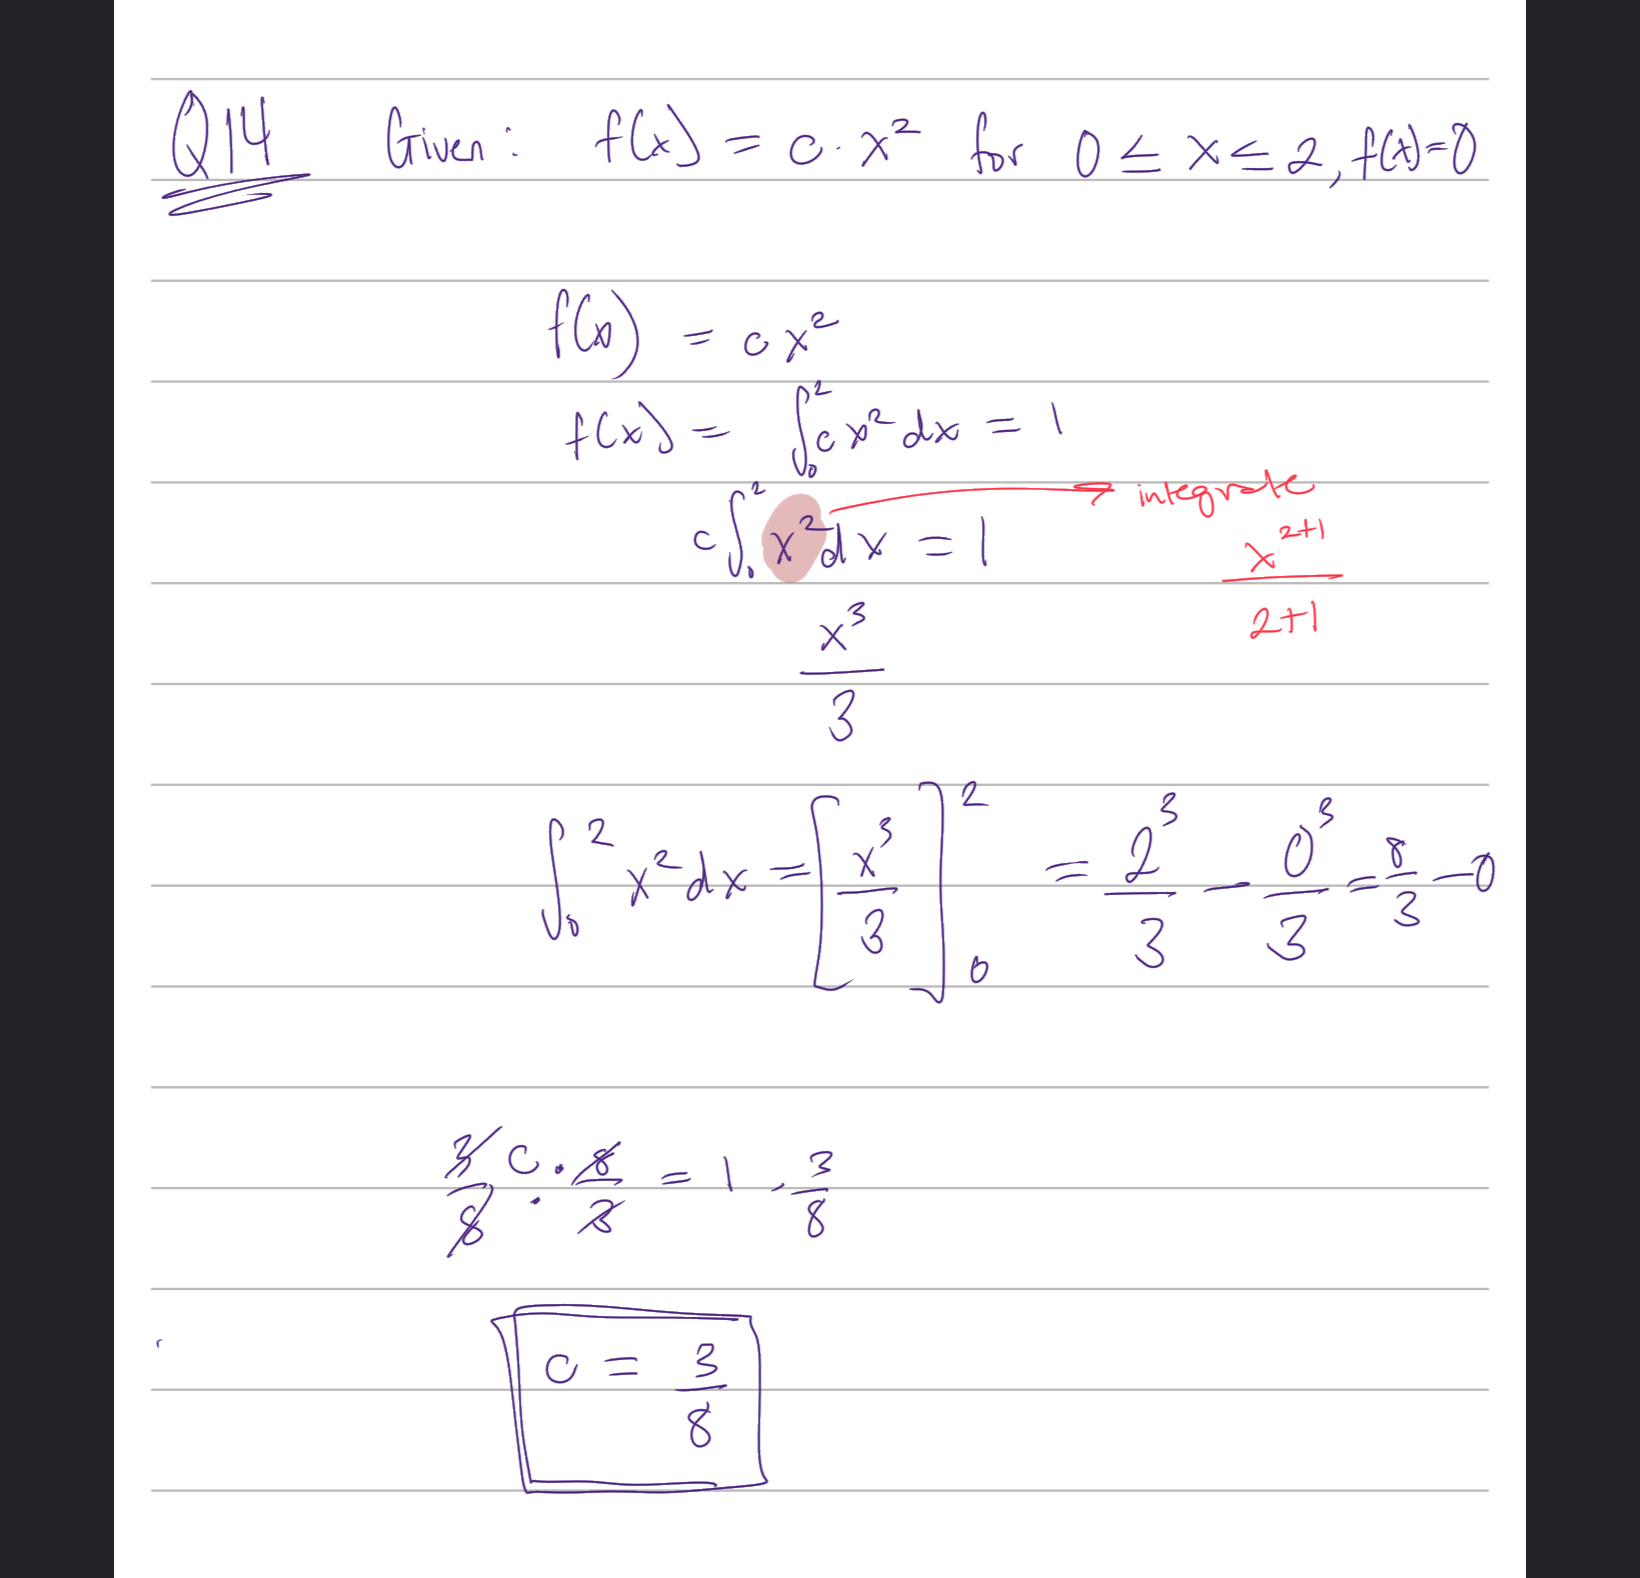

In [50]:
from IPython.display import Image
Image(filename="q14.png") 

Q15 Consider f(x) = c·e^(-x) for x ≥ 1. Find the normalizing constant c.

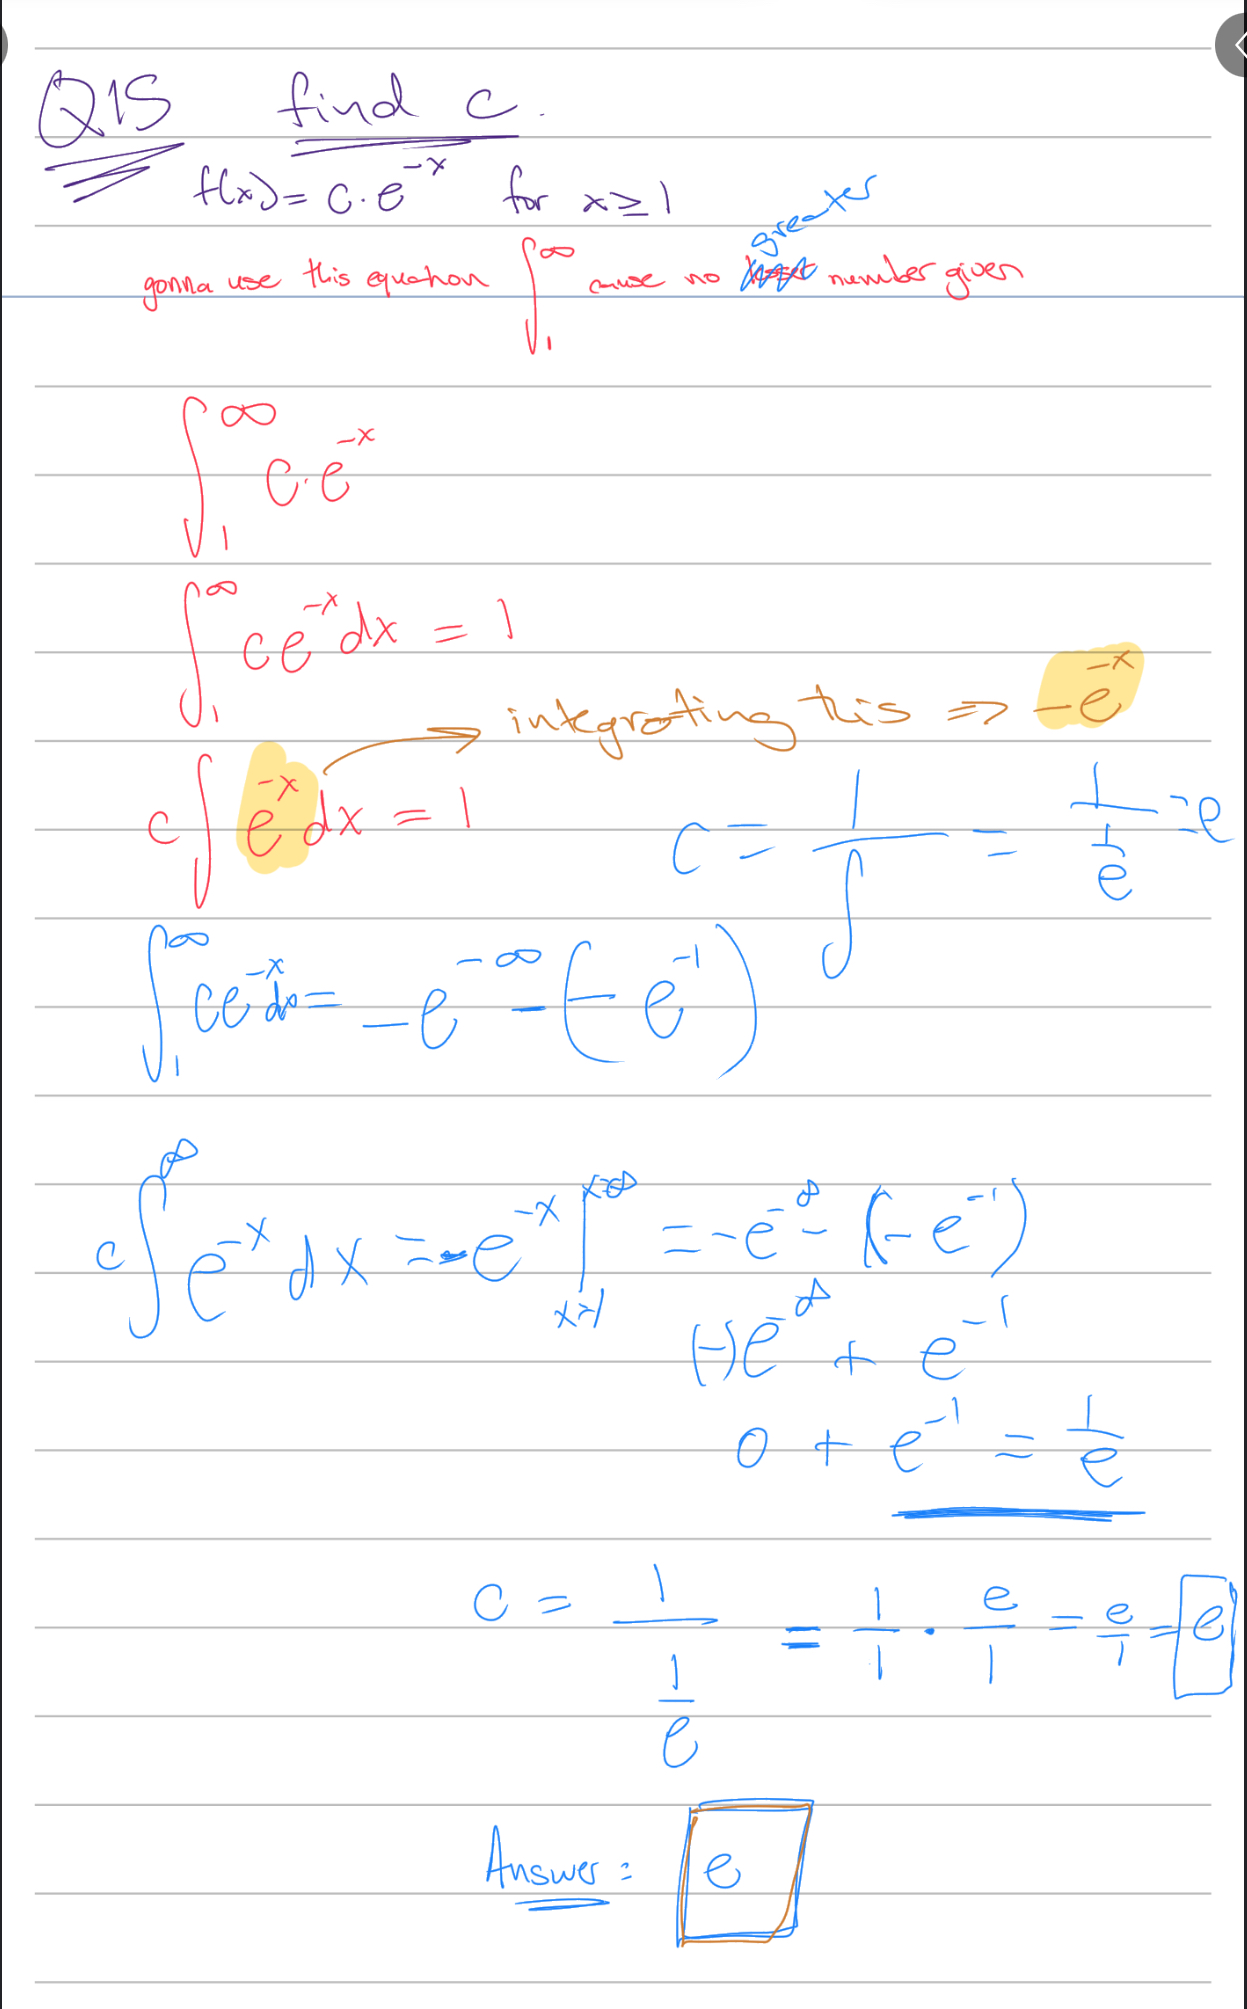

In [14]:
from IPython.display import Image
Image(filename="q15.png") 

Q16 Suppose X has density f(x) = 3x² for 0 ≤ x ≤ 1. Calculate P(0.25 < X < 0.75) by integration.

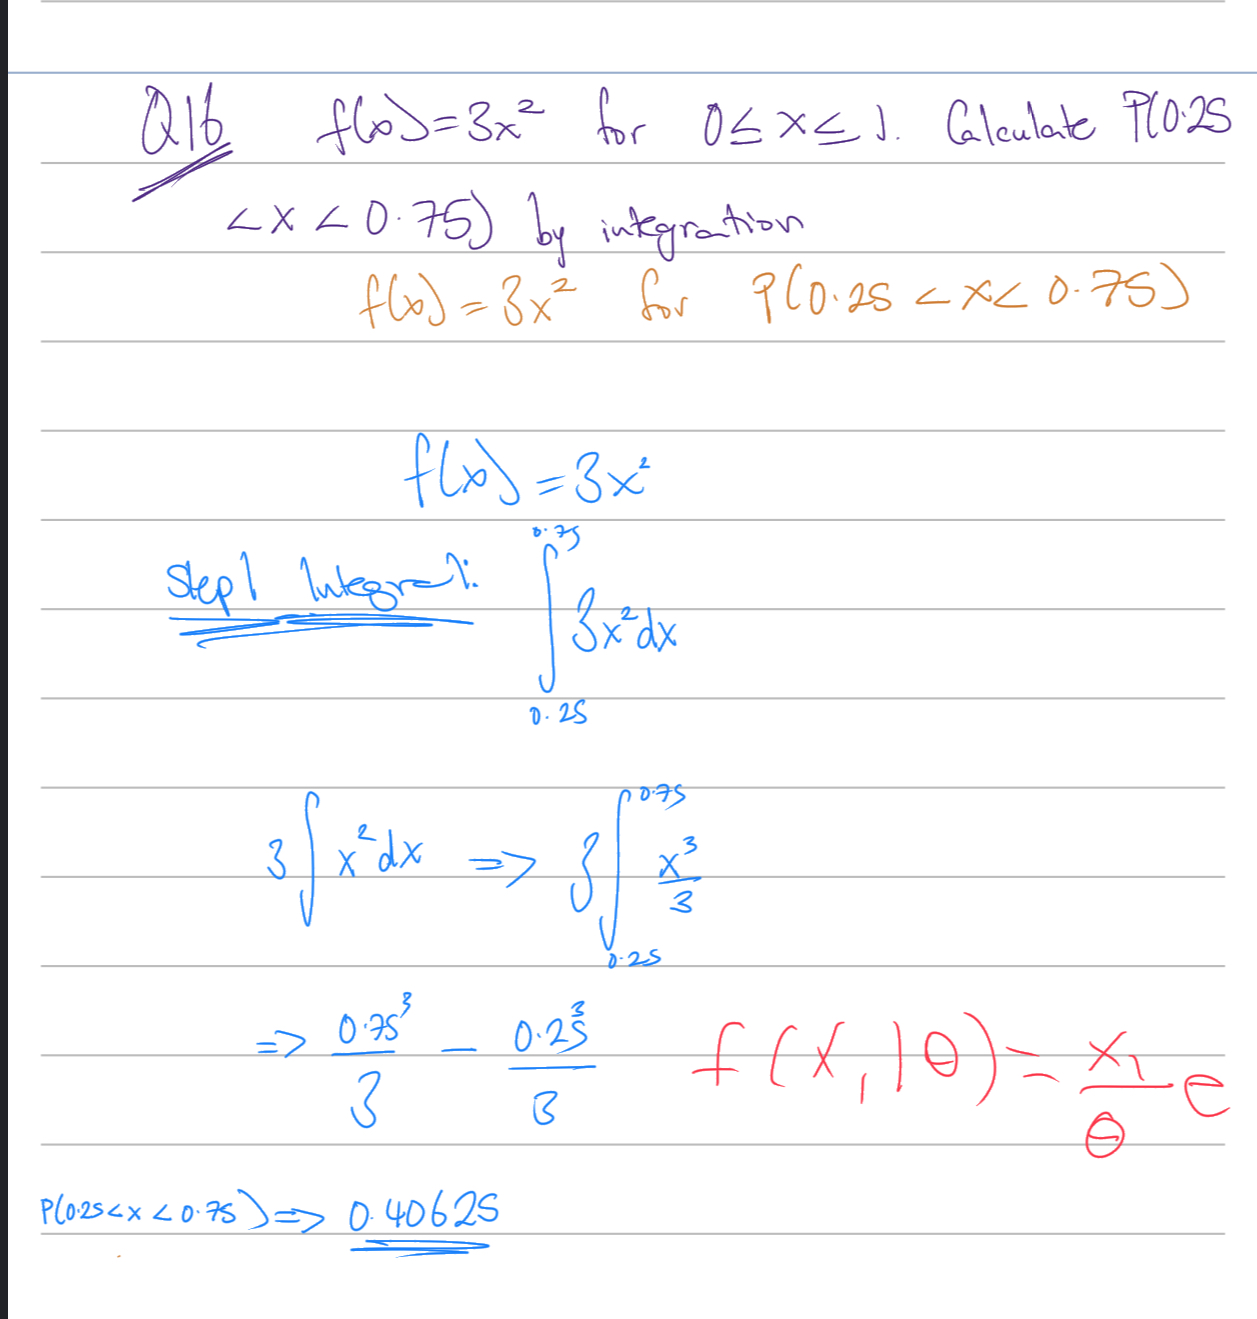

In [12]:
from IPython.display import Image
Image(filename="q16.png") 

### Estimation
Q17 The following data are believed to be from the Rayleigh distribtuion,
$$
f(x) = \frac{x}{\theta} e^{-\frac{x^2}{2\theta}}\qquad x\geq 0
$$

In [1]:
import numpy as np
np.random.seed(1)
3*np.sqrt(-2*np.log(1-np.random.uniform(size=10)))

array([3.1165534 , 4.78897218, 0.04537471, 2.54562951, 1.69019902,
       1.32057173, 1.92615249, 2.76253085, 3.01631327, 3.73246245])

(A) Calculate the maximum likelihood estimate of $\theta$.


(B) Create a plot of the estimated density function.

(C) With the estimated distribution, calculate  $ P(X\leq 1) $ .

### Simulation
Q18 Consider a system composed of two sensors, A and B, in sequence.


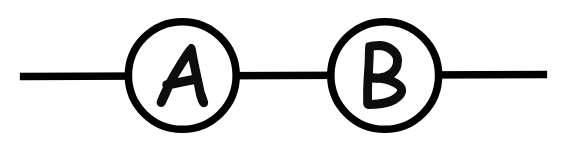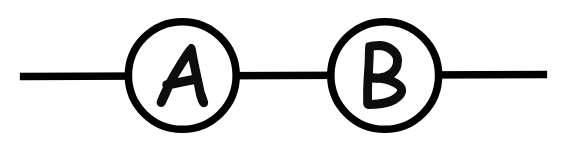


The system fails when either A or B fails. The failure time for sensor A follows an exponetial distribution with mean failure time of 3 years. The failure time for sensor B follows a Weibull distrubtion with scale = 3 and shape = 2.

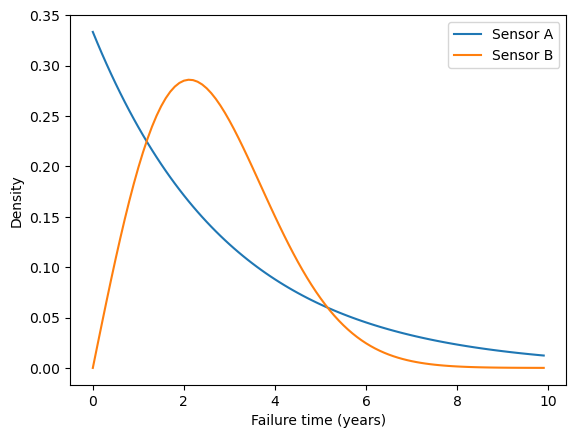

In [25]:
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
xx = np.arange(0,10,0.1)
zz = st.expon.pdf(xx,scale=3)
yy = st.weibull_min.pdf(xx, c = 2, scale = 3)
plt.close()
plt.plot(xx,zz, label = "Sensor A")
plt.plot(xx,yy, label = "Sensor B")
plt.xlabel("Failure time (years)")
plt.ylabel("Density")
plt.legend()

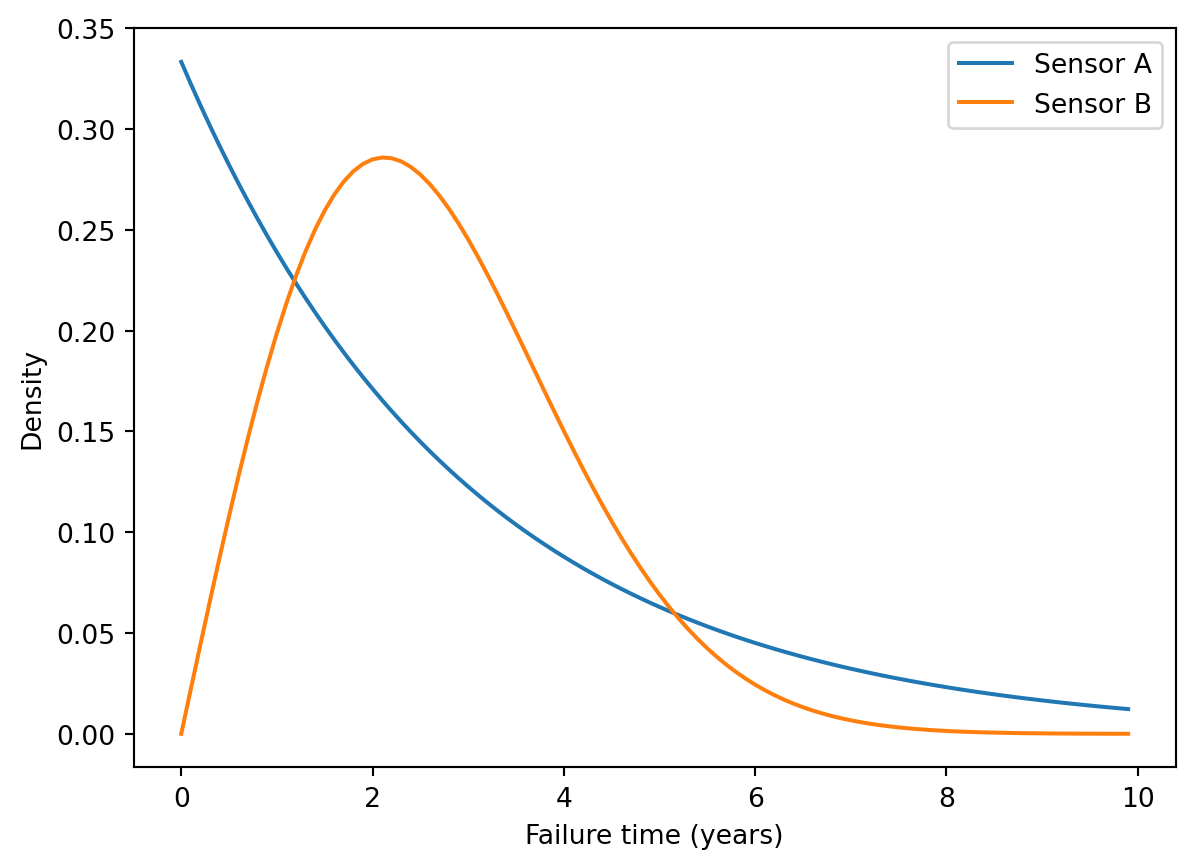

(A) Using simulation, generate a density estimate of the failure time for the improved system using the histogram. (Compare it to the previous distribution by placing the histograms of the old and new systems in the same plot.)

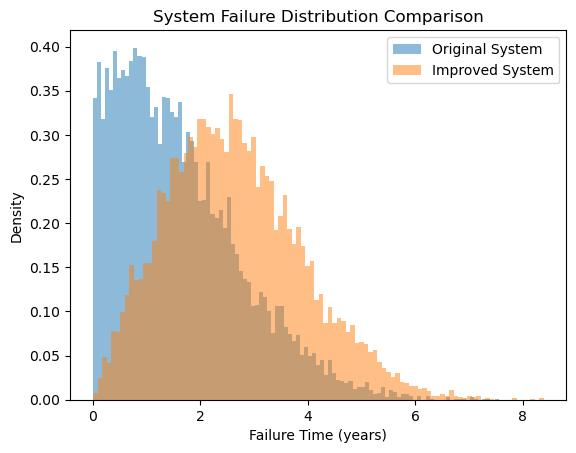

In [26]:
R = 10000
AF = st.expon.rvs(size=R,scale=3)  # A failures
BF = st.weibull_min.rvs(size=R, c = 2, scale = 3)  # B failures
SF = np.minimum(AF, BF)    # Old system failure times
plt.close()
plt.hist(SF, density = True,bins=100)
plt.close()
Summary = {
      "Mean":f"{SF.mean().item():.2f} (years)"
    , "Median":f"{np.median(SF).item():.2f} (years)"
    , "SD":f"{np.std(SF).item():.2f} (years)"
    , "Var":f"{np.var(SF).item():.2f} (years^2)"
}

#NEW SYSTEM
A_parallel1 = st.expon.rvs(size = R, scale = 3)
A_parallel2 = st.expon.rvs(size = R, scale = 3)
B_parallel1 = st.weibull_min.rvs(size=R, c = 2, scale = 3)  
B_parallel2 = st.weibull_min.rvs(size = R, c = 2, scale = 3)  
A_parallel_fail = np.maximum(A_parallel1, A_parallel2)
B_parallel_fail = np.maximum(B_parallel1, B_parallel2)

SF_new = np.minimum(A_parallel_fail, B_parallel_fail)

# Plot histogram comparisoN

plt.hist(SF, bins=100, alpha=0.5, density=True, label="Original System")
plt.hist(SF_new, bins=100, alpha=0.5, density=True, label="Improved System")
plt.legend()
plt.xlabel("Failure Time (years)")
plt.ylabel("Density")
plt.title("System Failure Distribution Comparison")
plt.show()

(B) Add another column to the table of summary measures for the improved system.

In [33]:
new_Summary = {
      "Mean":f"{SF_new.mean().item():.2f} (years)"
    , "Median":f"{np.median(SF_new).item():.2f} (years)"
    , "SD":f"{np.std(SF_new).item():.2f} (years)"
    , "Var":f"{np.var(SF_new).item():.2f} (years^2)"
}

print("old - " +str(Summary))
print("new - " + str(new_Summary))

old - {'Mean': '1.61 (years)', 'Median': '1.39 (years)', 'SD': '1.17 (years)', 'Var': '1.36 (years^2)'}
new - {'Mean': '2.64 (years)', 'Median': '2.54 (years)', 'SD': '1.26 (years)', 'Var': '1.59 (years^2)'}


(C) Create a single figure with the eCDF of both systems. Be sure to include a legend or labels.

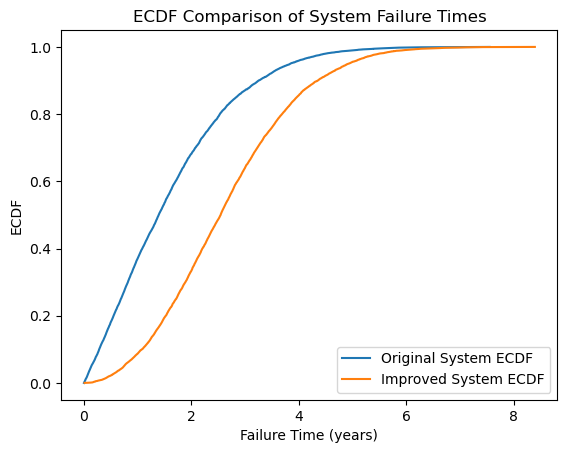

In [39]:

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data)+1) / len(data)
    return x, y

x_old, y_old = ecdf(SF)
x_new, y_new = ecdf(SF_new)

plt.close()
plt.plot(x_old, y_old, label="Original System ECDF")
plt.plot(x_new, y_new, label="Improved System ECDF")
plt.xlabel("Failure Time (years)")
plt.ylabel("ECDF")
plt.legend()
plt.title("ECDF Comparison of System Failure Times")
plt.show()


Q19 Ball bearings from machine A have diameters which follow a normal distribution with mean 10 and standard deviation 0.1. Machine B is more precise and generates ball bearings with the same mean but with a smaller standard deviation of 0.025. The additional precision comes at a cost: for every 1 ball bearing generated by machine B, machine A is able to produce 2 bearings.

(A) Generate a plot of the marginal density of ball bearing diameters generated at the factory. (The factory only has machines A and B.)

(B) Calculate the probability that a randomly selected ball bearing came from machine B given that its diameter is 9.9.

In [40]:
# machine a = mean 10 and  sd 0.1
# machine b = mean 10  SD 0.025 - for every 1 ball bearing generated by B, A produces 2

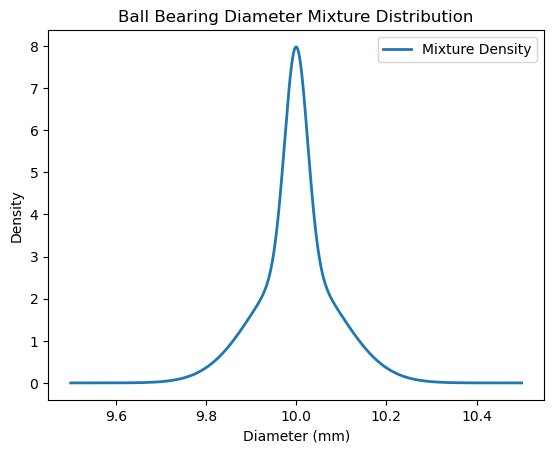

In [42]:
# a) 
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(9.5, 10.5, 1000)  # Changed from (0, 10) to see distributions
machine_A = norm.pdf(x, loc=10, scale=0.1)
machine_B = norm.pdf(x, loc=10, scale=0.025)

# Calculate each marginal density weight   
marg_den_A = 2/3  # A produces 2 for every 1 from B
marg_den_B = 1/3  # B produces 1 for every 2 from A

# Marginal density --> f(x) = wA*fA(x) + wB*fB(x)
marg_den_both = (marg_den_A * machine_A) + (marg_den_B * machine_B)

# Figure
plt.figure()
plt.plot(x, marg_den_both, label="Mixture Density", linewidth=2)
plt.title("Ball Bearing Diameter Mixture Distribution")
plt.xlabel("Diameter (mm)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [43]:
#(B) Calculate the probability that a randomly selected ball bearing came from machine B given that its diameter is 9.9.
from scipy.stats import norm

x0 = 9.9
wA, wB = 2/3, 1/3

fA_x0 = norm.pdf(x0, loc=10, scale=0.1)
fB_x0 = norm.pdf(x0, loc=10, scale=0.025)

posterior_B = (wB * fB_x0) / (wA * fA_x0 + wB * fB_x0)
print(posterior_B)


0.0011049464830364913


Q20 The Monte Hall problem is a classic game show. Contestants on the show where shown three doors. Behind one randomly selected door was a sportscar; behind the other doors were goats.

At the start of the game, contestants would select a door, say door A. Then, the host would open either door B or C to reveal a goat. At that point in the game, the host would ask the contestant if she would like to change her door selection. Once a contestant decided to stay or change, the host would open the chosen door to reveal the game prize, either a goat or a car.

Consider two strategies:

Always stay with the first door selected.
Always switch to the unopened door.
(A) Use simulation to determine the probability that each strategy wins the sportscar. The following code will simulate a single game. You may want to tweak it so that it generates results for R replicates.

In [44]:
import numpy as np

R = 10000  # number of simulated games

stay_wins = 0
switch_wins = 0

for _ in range(R):
    doors = [1, 2, 3]

    car = np.random.choice(doors)
    choice = np.random.choice(doors)

    # Host opens a goat door
    possible_opens = [d for d in doors if d != choice and d != car]
    host_opens = np.random.choice(possible_opens)

    # The remaining unopened door
    remaining = [d for d in doors if d not in (choice, host_opens)][0]

    # Stay strategy
    if choice == car:
        stay_wins += 1

    # Switch strategy
    if remaining == car:
        switch_wins += 1

print("Stay win probability:", stay_wins / R)
print("Switch win probability:", switch_wins / R)


Stay win probability: 0.3313
Switch win probability: 0.6687



(B) Modify the code so that it works for a game with N
 doors. Calculate the probability of winning for each strategy with N=4.

In [49]:
import numpy as np

def simulate_monty(N=10, R=10000):
    stay_wins = 0
    switch_wins = 0

    for _ in range(R):
        doors = list(range(1, N+1))

        car = np.random.choice(doors)
        choice = np.random.choice(doors)

        # Host opens N-2 goat doors
        goat_doors = [d for d in doors if d != car]
        host_opens = list(np.random.choice(
            [d for d in goat_doors if d != choice],
            size=N-2,
            replace=False
        ))

        # Remaining unopened door besides player's choice
        remaining = [d for d in doors if d not in host_opens and d != choice][0]

        # Stay strategy
        if choice == car:
            stay_wins += 1

        # Switch strategy
        if remaining == car:
            switch_wins += 1

    return stay_wins / R, switch_wins / R

stay, switch = simulate_monty(N=10, R=20000)
print("Stay win probability:", stay)
print("Switch win probability:", switch)


Stay win probability: 0.09845
Switch win probability: 0.90155
